This notebook builds a machine learning pipeline to detect and classify speech disfluencies using the UCLASS Stuttered Speech Clips dataset. We extract acoustic features from audio clips and train several classifiers, comparing traditional ML against a CNN.

In [ ]:
!pip install librosa

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os

Setting Up and Data Loading: Download dataset from Kaggle using API and load the labels.

In [ ]:
# Mount Google Drive
from google.colab import files
files.upload()  # upload your kaggle.json here when prompted

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"atharvaladwa","key":"c727e8868afee6b951acc6ed70ffb18c"}'}

In [ ]:
# Set up Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vudominhgiang/uclass-stuttered-speech-clips-sep-28k-format
!unzip uclass-stuttered-speech-clips-sep-28k-format.zip

Dataset URL: https://www.kaggle.com/datasets/vudominhgiang/uclass-stuttered-speech-clips-sep-28k-format
License(s): CC-BY-NC-SA-4.0
100% 500M/500M [00:04<00:00, 119MB/s]

Archive:  uclass-stuttered-speech-clips-sep-28k-format.zip
  inflating: README.md               
  inflating: annotations/M_0030_16y4m_1.syll.grid  
  inflating: annotations/M_0061_16y9m-1.syll.grid  
  inflating: annotations/M_0078_16y5m_1.syll.grid  
  inflating: annotations/M_0107_07y7m_1.syll.grid  
  inflating: annotations/M_0121_11y1m_1.syll.grid  
  inflating: annotations/M_0121_15y1m_1.syll.grid  
  inflating: annotations/M_0553_10y0m_1.syll.grid  
  inflating: annotations/M_0553_11y0m_1.syll.grid  
  inflating: annotations/M_1022_11y3m_1.syll.phon.grid  
  inflating: annotations/M_1023_11y3m_1.syll.phon.grid  
  inflating: annotations/M_1064_47y0m_1.syll.grid  
  inflating: annotations/M_1099_25y0m_1.syll.grid  
  inflating: annotations/M_1100_28y0m_1.syll.grid  
  inflating: annotations/M_1101_35y0m_1.syll.g

In [ ]:
import os
print(os.listdir('.'))
print()
print(os.listdir('clips'))

['.config', 'intermediate', 'annotations', 'audio', 'clips', 'audio_slicer.py', 'uclass-stuttered-speech-clips-sep-28k-format.zip', 'README.md', 'kaggle.json', 'process_annotations.py', 'sample_data']

['labels.csv', 'clips', 'metadata.json']


In [ ]:
import pandas as pd

df = pd.read_csv('clips/labels.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(4712, 7)
                                       filepath  Block  Prolongation  \
0  clips/clips/M_0030_16y4m_1_dysfluent_000.wav      1             0   
1  clips/clips/M_0030_16y4m_1_dysfluent_001.wav      1             0   
2  clips/clips/M_0030_16y4m_1_dysfluent_002.wav      1             0   
3  clips/clips/M_0030_16y4m_1_dysfluent_003.wav      1             0   
4  clips/clips/M_0030_16y4m_1_dysfluent_004.wav      0             1   

   SoundRep  WordRep  Interjection  NoStutteredWords  
0         1        0             0                 0  
1         1        0             0                 0  
2         1        0             0                 0  
3         1        0             0                 0  
4         0        0             1                 0  
['filepath', 'Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection', 'NoStutteredWords']


Explore the Data: Exame the structure, label distribution, and class imbalance.

In [ ]:
# How many clips of each type?
print(df[['Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection', 'NoStutteredWords']].sum())

# Any clips with multiple labels?
df['total_labels'] = df[['Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection', 'NoStutteredWords']].sum(axis=1)
print("\nLabel counts per clip:")
print(df['total_labels'].value_counts())

Block               1425
Prolongation         443
SoundRep            1650
WordRep              330
Interjection         930
NoStutteredWords    2222
dtype: int64

Label counts per clip:
total_labels
1    3081
2    1065
3     483
4      75
5       8
Name: count, dtype: int64


In [ ]:
y, sr = librosa.load('clips/clips/M_0030_16y4m_1_dysfluent_000.wav')

print(f"Audio length in samples: {len(y)}")
print(f"Sample rate: {sr}")
print(f"Audio length in seconds: {len(y)/sr:.2f}s")

Audio length in samples: 66150
Sample rate: 22050
Audio length in seconds: 3.00s


Audio Visualization: Load a dysfluent audio clip, listen to it, and visualize waveform and mel spectrogram to understand the signs of stuttering events.

In [ ]:
import IPython.display as ipd
ipd.Audio('clips/clips/M_0030_16y4m_1_dysfluent_000.wav')

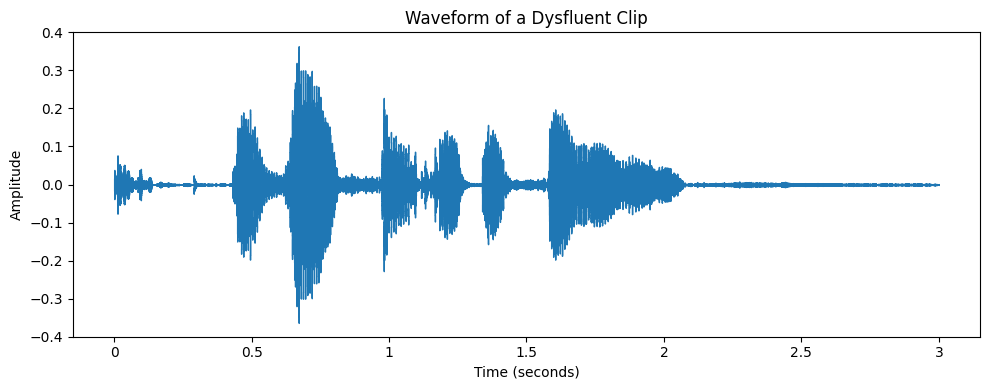

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))

# librosa.display.waveshow plots the raw audio wave
# y is the audio array, sr is the sample rate
librosa.display.waveshow(y, sr=sr)

plt.title('Waveform of a Dysfluent Clip')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.savefig('waveform.png', dpi=300, bbox_inches='tight')
plt.show()

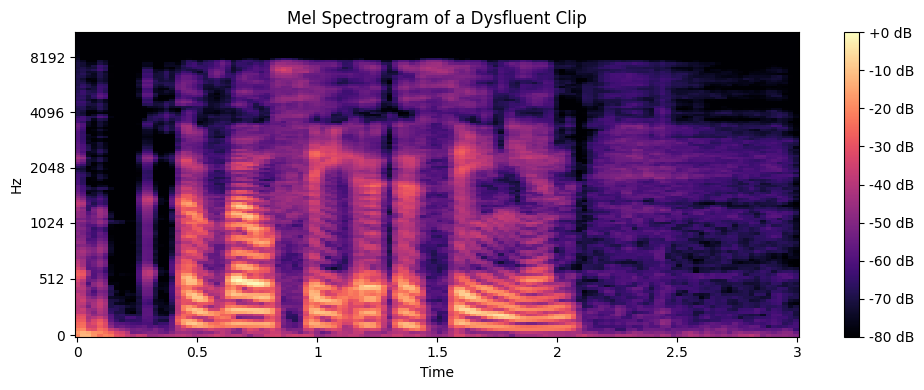

In [ ]:
# Compute a mel spectrogram
# n_mels=128 means we're looking at 128 frequency bands
# A mel spectrogram uses a frequency scale that matches human hearing
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

# Convert to decibels (log scale) so it's easier to read visually
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram of a Dysfluent Clip')
plt.tight_layout()
plt.savefig('spectrogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Extract MFCCs from the clip we already loaded
# n_mfcc=13 means we want 13 coefficients
# The output is a 2D array: 13 rows (coefficients) x time frames
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print(f"MFCC shape: {mfccs.shape}")
print(f"This means {mfccs.shape[0]} coefficients across {mfccs.shape[1]} time frames")

# Average across time so each clip = one vector of 13 numbers
mfccs_mean = np.mean(mfccs, axis=1)
print(f"\nAfter averaging: {mfccs_mean.shape}")
print(f"The 13 MFCC values: {mfccs_mean}")

MFCC shape: (13, 130)
This means 13 coefficients across 130 time frames

After averaging: (13,)
The 13 MFCC values: [-4.0341617e+02  9.8344635e+01 -1.3240463e+01  3.1463541e+01
  8.7063904e+00  2.1656704e+01 -1.1239158e+01  1.7808161e+01
 -1.1586883e+01 -1.0934570e+01 -4.0126941e-01 -2.7128825e+00
  7.1775045e+00]


Feature Extraction: Extract 13 MFCCs from each clip as the baseline feature vector. Each clip becomes a single vector of 13 numbers.

In [ ]:
# This will store our features and labels
features = []
labels = []
skipped = 0

# Loop through every row in the dataframe
for index, row in df.iterrows():
    filepath = row['filepath']

    try:
        # Load the audio clip
        y, sr = librosa.load(filepath)

        # Extract MFCCs and average across time
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)

        # Create binary label: 0 = fluent, 1 = stutter
        # NoStutteredWords=1 means fluent, so we flip it
        label = 0 if row['NoStutteredWords'] == 1 else 1

        features.append(mfccs_mean)
        labels.append(label)

    except Exception as e:
        skipped += 1
        continue

# Convert to numpy arrays
X = np.array(features)
y_labels = np.array(labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y_labels.shape}")
print(f"Skipped: {skipped} files")
print(f"Stutter clips: {y_labels.sum()}")
print(f"Fluent clips: {(y_labels == 0).sum()}")

Feature matrix shape: (4712, 13)
Labels shape: (4712,)
Skipped: 0 files
Stutter clips: 2490
Fluent clips: 2222


In [ ]:

print(f"Any NaN values in features: {np.isnan(X).any()}")
print(f"Any infinite values: {np.isinf(X).any()}")
print(f"Feature value range: {X.min():.2f} to {X.max():.2f}")

Any NaN values in features: False
Any infinite values: False
Feature value range: -1093.56 to 216.37


Binary Classification: Compares Random Forest, SVM, and Logistic Regression on detecting stutter vs fluent speech.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Split data into training and test sets
# test_size=0.2 means 80% training, 20% testing
# random_state=42 makes the split reproducible every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Train the Random Forest
# n_estimators=100 means 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Fluent', 'Stutter']))

Training samples: 3769
Test samples: 943

Accuracy: 0.9056
F1 Score: 0.9123

Detailed Report:
              precision    recall  f1-score   support

      Fluent       0.93      0.87      0.90       450
     Stutter       0.89      0.94      0.91       493

    accuracy                           0.91       943
   macro avg       0.91      0.90      0.91       943
weighted avg       0.91      0.91      0.91       943



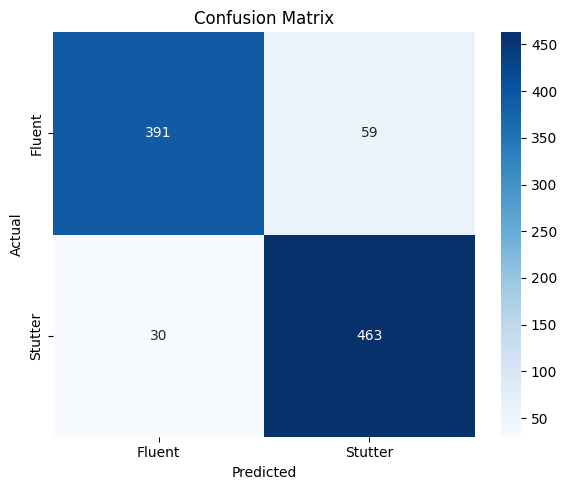

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fluent', 'Stutter'],
            yticklabels=['Fluent', 'Stutter'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# SVM works better when features are on the same scale
# StandardScaler makes each feature have mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_svm = svm_model.predict(X_test_scaled)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"SVM F1 Score: {f1_score(y_test, y_pred_svm):.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Fluent', 'Stutter']))

SVM Accuracy: 0.8643
SVM F1 Score: 0.8735

Detailed Report:
              precision    recall  f1-score   support

      Fluent       0.88      0.83      0.85       450
     Stutter       0.85      0.90      0.87       493

    accuracy                           0.86       943
   macro avg       0.87      0.86      0.86       943
weighted avg       0.87      0.86      0.86       943



In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression also needs scaled features like SVM
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression F1 Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Fluent', 'Stutter']))


Logistic Regression Accuracy: 0.7720
Logistic Regression F1 Score: 0.7902

Detailed Report:
              precision    recall  f1-score   support

      Fluent       0.79      0.72      0.75       450
     Stutter       0.76      0.82      0.79       493

    accuracy                           0.77       943
   macro avg       0.77      0.77      0.77       943
weighted avg       0.77      0.77      0.77       943



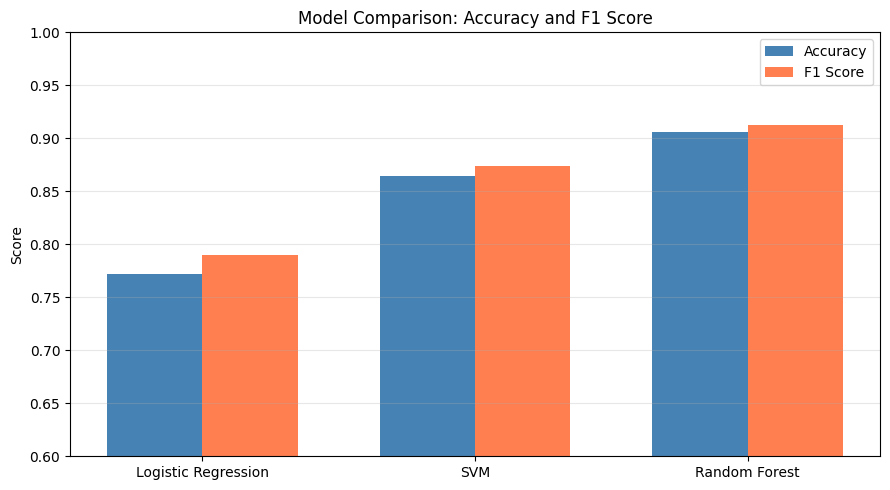

In [ ]:
models = ['Logistic Regression', 'SVM', 'Random Forest']
accuracies = [0.7720, 0.8643, 0.9056]
f1_scores = [0.7902, 0.8735, 0.9123]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy and F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Multi-Label Classification: Classify specific disfluency types simultaneously. Each clip can have multiple labels aside from clips with NoStutteredWords label.

In [ ]:
# Define the label columns
label_cols = ['Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection', 'NoStutteredWords']

# Extract all 6 labels for each clip
Y = df[label_cols].values

print(f"Label matrix shape: {Y.shape}")
print(f"\nFirst 5 rows:")
print(Y[:5])

Label matrix shape: (4712, 6)

First 5 rows:
[[1 0 1 0 0 0]
 [1 0 1 0 0 0]
 [1 0 1 0 0 0]
 [1 0 1 0 0 0]
 [0 1 0 0 1 0]]


In [ ]:
from sklearn.multioutput import MultiOutputClassifier

# Split using the same random state as before so it's consistent
X_train_ml, X_test_ml, Y_train_ml, Y_test_ml = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# MultiOutputClassifier trains one Random Forest per label
# So it's actually training 6 separate classifiers under the hood
ml_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ml_model.fit(X_train_ml, Y_train_ml)

# Predict
Y_pred_ml = ml_model.predict(X_test_ml)

print(f"Predictions shape: {Y_pred_ml.shape}")
print(f"\nFirst 5 predictions:")
print(Y_pred_ml[:5])
print(f"\nFirst 5 actual:")
print(Y_test_ml[:5])

Predictions shape: (943, 6)

First 5 predictions:
[[1 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [1 0 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 0 0]]

First 5 actual:
[[0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]
 [0 0 0 0 0 1]]


In [ ]:
  # training data pre-shuffling
ml_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ml_model.fit(X_train_ml, Y_train_ml)

Y_pred_ml = ml_model.predict(X_test_ml)

# Evaluate per label
from sklearn.metrics import classification_report

print("Per-label Classification Report:\n")
for i, label in enumerate(label_cols):
    f1 = f1_score(Y_test_ml[:, i], Y_pred_ml[:, i])
    acc = accuracy_score(Y_test_ml[:, i], Y_pred_ml[:, i])
    print(f"{label:20s} Accuracy: {acc:.4f}  F1: {f1:.4f}")


Per-label Classification Report:

Block                Accuracy: 0.8685  F1: 0.7687
Prolongation         Accuracy: 0.9427  F1: 0.4490
SoundRep             Accuracy: 0.8176  F1: 0.7296
WordRep              Accuracy: 0.9576  F1: 0.6552
Interjection         Accuracy: 0.8865  F1: 0.6625
NoStutteredWords     Accuracy: 0.9024  F1: 0.8938


Shuffling Analysis: The dataset was partially ordered by clip type. We evaluate the baseline model before and after shuffling to assess the impact it had.

In [ ]:
from sklearn.utils import shuffle

# Shuffle the entire dataset before splitting
X_shuffled, Y_shuffled = shuffle(X, Y, random_state=42)

# Now split
X_train_ml, X_test_ml, Y_train_ml, Y_test_ml = train_test_split(
    X_shuffled, Y_shuffled, test_size=0.2, random_state=42
)

# Check the first 5 test labels now
print("First 5 actual labels after shuffling:")
print(Y_test_ml[:5])
print(f"\nFluent clips in test set: {Y_test_ml[:, 5].sum()}")
print(f"Total test clips: {len(Y_test_ml)}")

First 5 actual labels after shuffling:
[[0 0 0 0 0 1]
 [0 0 1 0 1 0]
 [1 0 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 0 0 0]]

Fluent clips in test set: 434
Total test clips: 943


In [ ]:
  # Retrain on shuffled data
ml_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ml_model.fit(X_train_ml, Y_train_ml)

Y_pred_ml = ml_model.predict(X_test_ml)

# Evaluate per label
from sklearn.metrics import classification_report

print("Per-label Classification Report:\n")
for i, label in enumerate(label_cols):
    f1 = f1_score(Y_test_ml[:, i], Y_pred_ml[:, i])
    acc = accuracy_score(Y_test_ml[:, i], Y_pred_ml[:, i])
    print(f"{label:20s} Accuracy: {acc:.4f}  F1: {f1:.4f}")


Per-label Classification Report:

Block                Accuracy: 0.8547  F1: 0.7439
Prolongation         Accuracy: 0.9109  F1: 0.3731
SoundRep             Accuracy: 0.8155  F1: 0.7434
WordRep              Accuracy: 0.9650  F1: 0.6733
Interjection         Accuracy: 0.8834  F1: 0.6382
NoStutteredWords     Accuracy: 0.9067  F1: 0.8952


SMOTE Experiment: Attempt to address class imbalance using synthetic oversampling. Applied to 13-feature baseline

In [ ]:
!pip install imbalanced-learn

In [ ]:
!pip install iterative-stratification

In [ ]:
from imblearn.over_sampling import SMOTE
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
print("both imported successfully")

both imported successfully


In [ ]:
from imblearn.over_sampling import SMOTE

X_resampled_list = [X_train_ml]
Y_resampled_list = [Y_train_ml]

for i, label in enumerate(label_cols):
    pos_count = Y_train_ml[:, i].sum()
    neg_count = len(Y_train_ml) - pos_count

    if pos_count < neg_count * 0.4:
        print(f"Applying SMOTE to {label} (positive samples: {pos_count})")
        smote = SMOTE(random_state=42, k_neighbors=5)

        X_temp, y_temp = smote.fit_resample(X_train_ml, Y_train_ml[:, i])

        # Only keep the new synthetic samples
        n_new = len(X_temp) - len(X_train_ml)
        if n_new > 0:
            new_X = X_temp[len(X_train_ml):]
            new_Y = np.zeros((n_new, len(label_cols)), dtype=int)
            new_Y[:, i] = 1
            X_resampled_list.append(new_X)
            Y_resampled_list.append(new_Y)
            print(f"  Added {n_new} synthetic samples")

X_resampled = np.vstack(X_resampled_list)
Y_resampled = np.vstack(Y_resampled_list)

print(f"\nOriginal training size: {len(X_train_ml)}")
print(f"Resampled training size: {len(X_resampled)}")

Applying SMOTE to Prolongation (positive samples: 339)
  Added 3091 synthetic samples
Applying SMOTE to WordRep (positive samples: 267)
  Added 3235 synthetic samples
Applying SMOTE to Interjection (positive samples: 752)
  Added 2265 synthetic samples

Original training size: 3769
Resampled training size: 12360


In [ ]:
ml_model_smote = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ml_model_smote.fit(X_resampled, Y_resampled)

Y_pred_smote = ml_model_smote.predict(X_test_ml)

print("Per-label F1 Scores: Before vs After SMOTE\n")
print(f"{'Label':20s} {'Before':>8} {'After':>8} {'Change':>8}")
print("-" * 48)

before_f1 = [0.7439, 0.3731, 0.7434, 0.6733, 0.6382, 0.8952]

for i, label in enumerate(label_cols):
    after = f1_score(Y_test_ml[:, i], Y_pred_smote[:, i])
    change = after - before_f1[i]
    direction = "▲" if change > 0 else "▼"
    print(f"{label:20s} {before_f1[i]:>8.4f} {after:>8.4f} {direction}{abs(change):.4f}")

Per-label F1 Scores: Before vs After SMOTE

Label                  Before    After   Change
------------------------------------------------
Block                  0.7439   0.3543 ▼0.3896
Prolongation           0.3731   0.4713 ▲0.0982
SoundRep               0.7434   0.4454 ▼0.2980
WordRep                0.6733   0.6723 ▼0.0010
Interjection           0.6382   0.5600 ▼0.0782
NoStutteredWords       0.8952   0.8761 ▼0.0191


Expand Feature Count: Expand from 13 MFCC features to a 29-feature vector including MFCC standard deviations, zero crossing rate, RMS energy, and spectral centroid.

In [ ]:
def extract_features(y, sr):
    # MFCC mean and std
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfccs, axis=1)
    mfcc_std = np.std(mfccs, axis=1)

    # Zero crossing rate mean
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    # RMS energy mean
    rms = np.mean(librosa.feature.rms(y=y))

    # Spectral centroid mean
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

    # Concatenate everything into one vector
    return np.concatenate([mfcc_mean, mfcc_std, [zcr, rms, centroid]])

# Test on one clip first
y_test_clip, sr_test_clip = librosa.load('clips/clips/M_0030_16y4m_1_dysfluent_000.wav')
test_features = extract_features(y_test_clip, sr_test_clip)
print(f"New feature vector size: {test_features.shape}")

New feature vector size: (29,)


In [ ]:
features_v2 = []
skipped = 0

for index, row in df.iterrows():
    filepath = row['filepath']

    try:
        y, sr = librosa.load(filepath)
        feat = extract_features(y, sr)
        features_v2.append(feat)

    except Exception as e:
        skipped += 1
        continue

X_v2 = np.array(features_v2)

print(f"New feature matrix shape: {X_v2.shape}")
print(f"Skipped: {skipped} files")
print(f"Any NaN: {np.isnan(X_v2).any()}")
print(f"Any Inf: {np.isinf(X_v2).any()}")

New feature matrix shape: (4712, 29)
Skipped: 0 files
Any NaN: False
Any Inf: False


In [ ]:
# Shuffle first
X_v2_shuffled, Y_shuffled = shuffle(X_v2, Y, random_state=42)

# Split
X_train_v2, X_test_v2, Y_train_v2, Y_test_v2 = train_test_split(
    X_v2_shuffled, Y_shuffled, test_size=0.2, random_state=42
)

# Binary labels for Option A
y_binary = np.array([0 if row[5] == 1 else 1 for row in Y_shuffled])
_, _, y_train_bin, y_test_bin = train_test_split(
    X_v2_shuffled, y_binary, test_size=0.2, random_state=42
)

# Train Option A with new features
rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train_bin)
y_pred_v2 = rf_v2.predict(X_test_v2)

print("=== Option A: Binary Classification ===")
print(f"Old Accuracy: 0.9056  New Accuracy: {accuracy_score(y_test_bin, y_pred_v2):.4f}")
print(f"Old F1:       0.9123  New F1:       {f1_score(y_test_bin, y_pred_v2):.4f}")

# Train Option B with new features
ml_v2 = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ml_v2.fit(X_train_v2, Y_train_v2)
Y_pred_v2 = ml_v2.predict(X_test_v2)

print("\n=== Option B: Multi-label Classification ===")
print(f"\n{'Label':20s} {'Before':>8} {'After':>8} {'Change':>8}")
print("-" * 48)

before_f1 = [0.7439, 0.3731, 0.7434, 0.6733, 0.6382, 0.8952]

for i, label in enumerate(label_cols):
    after = f1_score(Y_test_v2[:, i], Y_pred_v2[:, i])
    change = after - before_f1[i]
    direction = "▲" if change > 0 else "▼"
    print(f"{label:20s} {before_f1[i]:>8.4f} {after:>8.4f} {direction}{abs(change):.4f}")

=== Option A: Binary Classification ===
Old Accuracy: 0.9056  New Accuracy: 0.9279
Old F1:       0.9123  New F1:       0.9347

=== Option B: Multi-label Classification ===

Label                  Before    After   Change
------------------------------------------------
Block                  0.7439   0.7790 ▲0.0351
Prolongation           0.3731   0.4412 ▲0.0681
SoundRep               0.7434   0.7710 ▲0.0276
WordRep                0.6733   0.7379 ▲0.0646
Interjection           0.6382   0.6553 ▲0.0171
NoStutteredWords       0.8952   0.9167 ▲0.0215


Classifier Chain: Train classifiers sequentially so each one receives the predictions of preceding classifiers, accounting for label co-occurrence.

In [ ]:
from sklearn.multioutput import ClassifierChain

# Order from most to least common
chain_order = [5, 2, 0, 4, 1, 3]  # indices of label_cols

chain_model = ClassifierChain(
    RandomForestClassifier(n_estimators=100, random_state=42),
    order=chain_order,
    random_state=42
)

chain_model.fit(X_train_v2, Y_train_v2)
Y_pred_chain = chain_model.predict(X_test_v2)

print(f"{'Label':20s} {'MultiOutput':>12} {'Chain':>8} {'Change':>8}")
print("-" * 52)

before_f1 = [0.7790, 0.4412, 0.7710, 0.7379, 0.6553, 0.9167]

for i, label in enumerate(label_cols):
    after = f1_score(Y_test_v2[:, i], Y_pred_chain[:, i])
    change = after - before_f1[i]
    direction = "▲" if change > 0 else "▼"
    print(f"{label:20s} {before_f1[i]:>12.4f} {after:>8.4f} {direction}{abs(change):.4f}")

Label                 MultiOutput    Chain   Change
----------------------------------------------------
Block                      0.7790   0.7932 ▲0.0142
Prolongation               0.4412   0.4604 ▲0.0192
SoundRep                   0.7710   0.8037 ▲0.0327
WordRep                    0.7379   0.7222 ▼0.0157
Interjection               0.6553   0.6588 ▲0.0035
NoStutteredWords           0.9167   0.9167 ▼0.0000


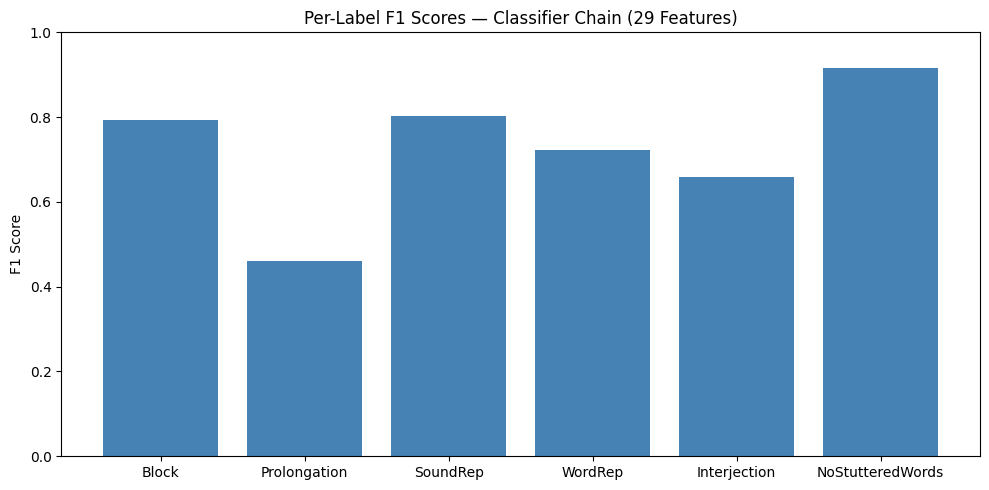

In [ ]:
labels_names = ['Block', 'Prolongation', 'SoundRep', 'WordRep', 'Interjection', 'NoStutteredWords']
chain_f1 = [0.7932, 0.4604, 0.8037, 0.7222, 0.6588, 0.9167]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels_names, chain_f1, color='steelblue')
plt.ylim(0, 1.0)
plt.ylabel('F1 Score')
plt.title('Per-Label F1 Scores — Classifier Chain (29 Features)')
plt.tight_layout()
plt.savefig('multilabel_f1.png', dpi=300, bbox_inches='tight')
plt.show()

Deep Learning Experiment: Evaluate whether a convolutional neural network (CNN) trained on mel spectrograms outperforms traditional ML on this dataset.

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
def extract_spectrogram(filepath, n_mels=128, target_size=(128, 128)):
    # Load audio
    y, sr = librosa.load(filepath)

    # Compute mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)

    # Convert to decibels
    S_db = librosa.power_to_db(S, ref=np.max)

    # Resize to fixed size so every clip produces same shaped input
    from sklearn.preprocessing import MinMaxScaler

    # Normalize to 0-1 range
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min())

    # Resize to target size using numpy
    from PIL import Image
    img = Image.fromarray(S_norm)
    img_resized = img.resize(target_size)

    return np.array(img_resized)

# Test on one clip
test_spec = extract_spectrogram('clips/clips/M_0030_16y4m_1_dysfluent_000.wav')
print(f"Spectrogram shape: {test_spec.shape}")

Spectrogram shape: (128, 128)


In [ ]:
spectrograms = []
skipped = 0

for index, row in df.iterrows():
    filepath = row['filepath']

    try:
        spec = extract_spectrogram(filepath)
        spectrograms.append(spec)

    except Exception as e:
        skipped += 1
        continue

# Convert to numpy array and add channel dimension
# CNNs expect input shape (samples, height, width, channels)
# Since spectrograms are grayscale, channels=1
X_cnn = np.array(spectrograms)
X_cnn = X_cnn[..., np.newaxis]

print(f"CNN input shape: {X_cnn.shape}")
print(f"Skipped: {skipped} files")
print(f"Any NaN: {np.isnan(X_cnn).any()}")

CNN input shape: (4712, 128, 128, 1)
Skipped: 0 files
Any NaN: False


In [ ]:
from sklearn.utils import shuffle

# Shuffle and split
X_cnn_shuffled, Y_shuffled_cnn = shuffle(X_cnn, Y, random_state=42)

X_train_cnn, X_test_cnn, Y_train_cnn, Y_test_cnn = train_test_split(
    X_cnn_shuffled, Y_shuffled_cnn, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_cnn)}")
print(f"Test samples: {len(X_test_cnn)}")

Training samples: 3769
Test samples: 943


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # First conv block
    # 32 filters, each 3x3, looks for simple patterns like edges
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),  # halves the spatial dimensions

    # Second conv block
    # 64 filters, looks for more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third conv block
    # 128 filters, looks for high level patterns
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten 2D to 1D
    layers.Flatten(),

    # Dropout randomly turns off 50% of neurons during training
    # prevents the model from memorizing the training data
    layers.Dropout(0.5),

    # Dense layer combines all learned features
    layers.Dense(256, activation='relu'),

    # Output layer - 6 neurons, one per label
    # sigmoid outputs a probability between 0 and 1 for each label
    layers.Dense(6, activation='sigmoid')
])

# Compile the model
# binary_crossentropy works for multi-label since each label is independent
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,998 (24.86 MB)

 Trainable params: 6,516,998 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',  # watch validation loss
    patience=5,          # stop if no improvement for 5 epochs
    restore_best_weights=True  # keep the best version of the model
)

history = model.fit(
    X_train_cnn, Y_train_cnn,
    epochs=30,           # maximum number of training passes
    batch_size=32,       # how many clips to process at once
    validation_split=0.2,# use 20% of training data to monitor progress
    callbacks=[early_stop]
)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 646ms/step - accuracy: 0.4978 - loss: 0.4639 - val_accuracy: 0.5292 - val_loss: 0.4045
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 59s 617ms/step - accuracy: 0.5940 - loss: 0.3762 - val_accuracy: 0.5862 - val_loss: 0.3744
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 631ms/step - accuracy: 0.6385 - loss: 0.3392 - val_accuracy: 0.6326 - val_loss: 0.3493
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 82s 632ms/step - accuracy: 0.6637 - loss: 0.3071 - val_accuracy: 0.5995 - val_loss: 0.3576
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 656ms/step - accuracy: 0.6766 - loss: 0.2886 - val_accuracy: 0.6326 - val_loss: 0.3470
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 647ms/step - accuracy: 0.7035 - loss: 0.2583 - val_accuracy: 0.6485 - val_loss: 0.3267
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 59s 626ms/step - accuracy: 0.7121 - loss: 0.2294 - val_accuracy: 0.6711 - val_loss: 0.3442
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 616ms/step - accuracy: 0.7367 - loss: 0.2098 - val_accu

In [ ]:
# Convert probabilities to binary predictions
Y_pred_cnn = (model.predict(X_test_cnn) > 0.5).astype(int)

print(f"{'Label':20s} {'Chain RF':>10} {'CNN':>8} {'Change':>8}")
print("-" * 50)

before_f1 = [0.7932, 0.4604, 0.8037, 0.7222, 0.6588, 0.9167]

for i, label in enumerate(label_cols):
    after = f1_score(Y_test_cnn[:, i], Y_pred_cnn[:, i])
    change = after - before_f1[i]
    direction = "▲" if change > 0 else "▼"
    print(f"{label:20s} {before_f1[i]:>10.4f} {after:>8.4f} {direction}{abs(change):.4f}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step
Label                  Chain RF      CNN   Change
--------------------------------------------------
Block                    0.7932   0.6514 ▼0.1418
Prolongation             0.4604   0.0374 ▼0.4230
SoundRep                 0.8037   0.7194 ▼0.0843
WordRep                  0.7222   0.3368 ▼0.3854
Interjection             0.6588   0.4968 ▼0.1620
NoStutteredWords         0.9167   0.8765 ▼0.0402
